# Predictive Maintenance Project

This notebook builds a complete binary classification workflow for predictive maintenance. The goal is to predict whether a machine will fail (`Target = 1`) using sensor and product information.

Models covered:
- Logistic Regression
- Decision Tree Classifier

Workflow:
1. Import libraries
2. Load and understand the data
3. Perform EDA and document insights
4. Check outliers using boxplots and IQR
5. Handle encoding, scaling, and class imbalance
6. Train/test split
7. Hyperparameter tuning
8. Validation and model comparison
9. Evaluate Precision, Accuracy, Recall, and F1-score
10. Save the best model


In [24]:
# Core data libraries
import os
import pickle
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing and modeling tools
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

## 1. Load Dataset

The dataset is loaded from the `Data` folder. We keep paths relative to the project root so the notebook remains portable.

In [25]:
# Resolve paths from the notebook folder to the project root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebook" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "Data" / "predictive_maintenance.csv"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [26]:
# Basic dataset shape and column information.
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.info()

Rows: 10,000
Columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


## 2. Basic EDA

We inspect missing values, duplicate rows, target distribution, categorical distributions, and numerical summaries. This helps decide preprocessing steps and evaluation strategy.

In [27]:
# Missing values check.
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [28]:
# Duplicate rows check.
print(f"Duplicate rows: {df.duplicated().sum():,}")

Duplicate rows: 0


In [29]:
# Numerical summary.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Target,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0


In [30]:
# Target distribution. Predictive maintenance data is usually imbalanced because failures are rare.
target_counts = df["Target"].value_counts().rename(index={0: "No Failure", 1: "Failure"})
target_pct = df["Target"].value_counts(normalize=True).mul(100).rename(index={0: "No Failure", 1: "Failure"})
pd.DataFrame({"count": target_counts, "percentage": target_pct.round(2)})

,count,percentage
Target,,
No Failure,9661,96.61
Failure,339,3.39


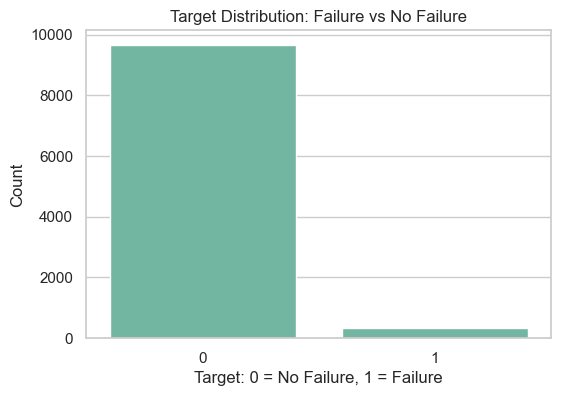

In [31]:
# Visualize class imbalance.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Target")
plt.title("Target Distribution: Failure vs No Failure")
plt.xlabel("Target: 0 = No Failure, 1 = Failure")
plt.ylabel("Count")
plt.show()

In [32]:
# Failure Type distribution gives operational context but will not be used as a feature,
# because it is directly related to the target and would cause target leakage.
df["Failure Type"].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [33]:
# Product Type distribution. This is a valid categorical input feature.
df["Type"].value_counts(normalize=True).mul(100).round(2)

Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64

### EDA Learning Insights

- `Target` is the main binary label: `0` means no failure and `1` means failure.
- `Failure Type` is not used as an input feature because it is only known after a failure outcome is known. Including it would leak the answer into training.
- `UDI` is only a row identifier and should be removed.
- `Product ID` is a high-cardinality identifier and usually does not generalize well for future machines, so it is removed.
- `Type` is a low-cardinality categorical feature and should be encoded.
- Failures are expected to be rare, so accuracy alone can be misleading. We must inspect recall, precision, and F1-score.

## 3. Numerical Distributions and Outliers

Boxplots help identify potential outliers. We also calculate IQR limits for every numerical feature. For this project, we do not automatically remove outliers because extreme sensor values may be exactly the kind of signal that predicts machine failure.

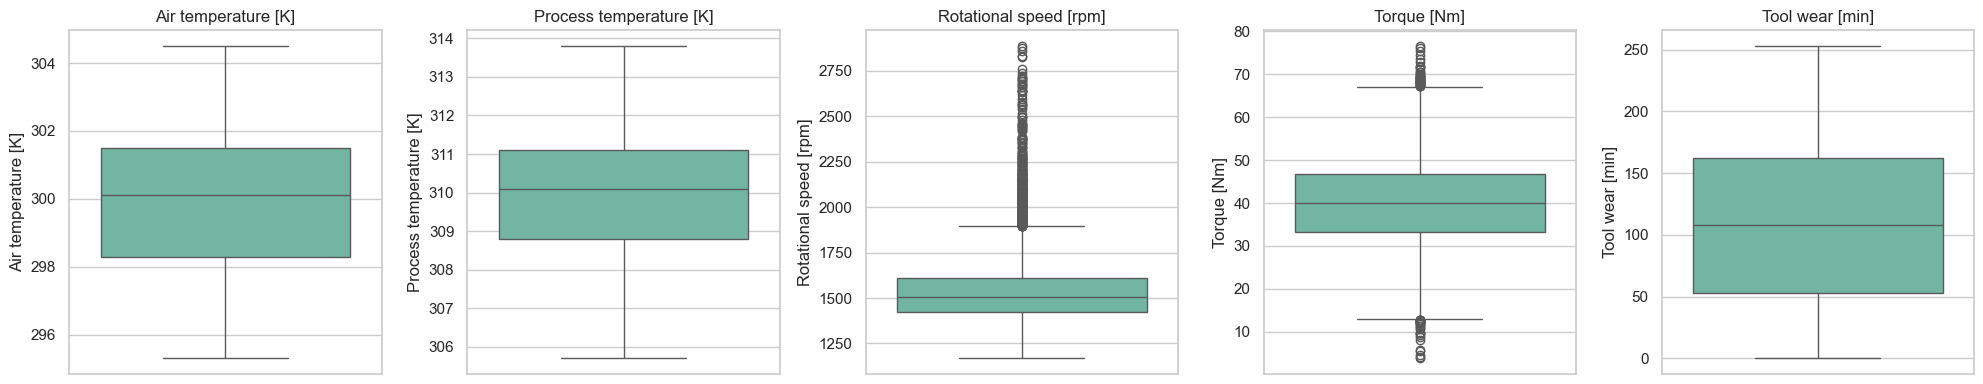

In [34]:
numeric_features_for_eda = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

# Boxplots by feature to visually inspect outliers.
fig, axes = plt.subplots(1, len(numeric_features_for_eda), figsize=(20, 4))
for ax, col in zip(axes, numeric_features_for_eda):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [35]:
# IQR outlier summary. This quantifies how many values lie below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.
iqr_rows = []
for col in numeric_features_for_eda:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    iqr_rows.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers": outlier_count,
        "outlier_percentage": round(outlier_count / len(df) * 100, 2),
    })

pd.DataFrame(iqr_rows)

,feature,lower_bound,upper_bound,outliers,outlier_percentage
0,Air temperature [K],293.50,306.30,0,0.00
1,Process temperature [K],305.35,314.55,0,0.00
2,Rotational speed [rpm],1139.50,1895.50,418,4.18
3,Torque [Nm],12.80,67.20,69,0.69
4,Tool wear [min],-110.50,325.50,0,0.00


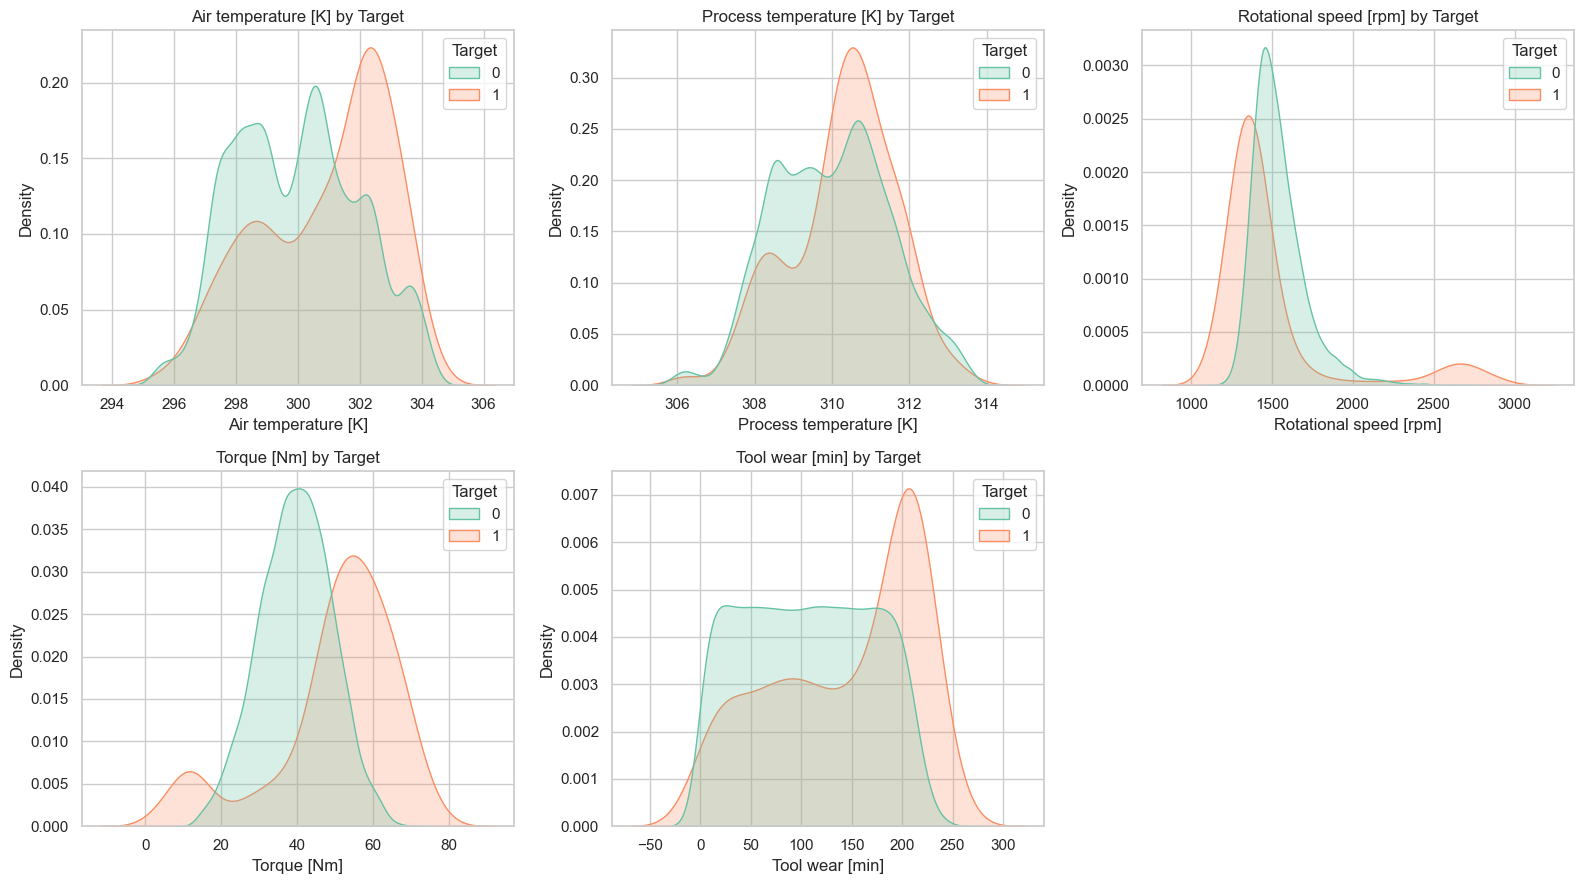

In [ ]:
# Compare numerical feature distributions against the failure label.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, numeric_features_for_eda):
    sns.kdeplot(data=df, x=col, hue="Target", common_norm=False, fill=True, ax=ax)
    ax.set_title(f"{col} by Target")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

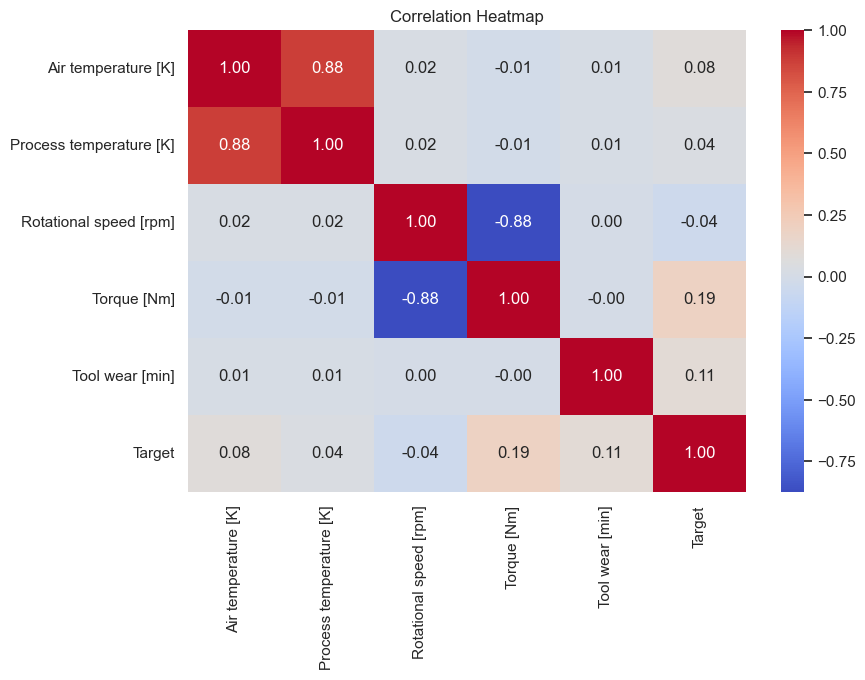

In [37]:
# Correlation heatmap for numerical columns and target.
corr_cols = numeric_features_for_eda + ["Target"]
plt.figure(figsize=(9, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 4. Feature Selection and Preprocessing Strategy

Columns removed:
- `UDI`: row identifier.
- `Product ID`: high-cardinality product identifier; likely not reliable for generalization.
- `Failure Type`: target leakage for binary failure prediction.

Encoding:
- `Type` is nominal categorical data (`L`, `M`, `H`). One-hot encoding is appropriate because there is no true numeric order.

Scaling:
- Logistic Regression benefits from scaled numerical features.
- Decision Trees do not need scaling, but using a shared preprocessing pipeline keeps model comparison clean.

Class imbalance:
- We use `class_weight='balanced'` in both models so failures receive higher training weight.

In [38]:
target = "Target"
drop_columns = ["UDI", "Product ID", "Failure Type", target]

X = df.drop(columns=drop_columns)
y = df[target]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Categorical features: ['Type']


In [ ]:
# Preprocessing pipeline:
# - Median imputation is robust to outliers for numeric columns.
# - Most-frequent imples missingutation hand caintegorical values.
# - OneHotEncoder converts Type into machine-readable bary indicators.
# - StandardScaler standardizes numeric features for Logistic Regression.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

## 5. Train/Test Split

We use a stratified split so the rare failure class keeps the same proportion in both train and test sets.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Train target distribution:
Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Test target distribution:
Target
0    0.966
1    0.034
Name: proportion, dtype: float64


## 6. Simple Model Training With Hyperparameter Tuning

We tune both models using a simple validation split from the training data. This avoids `GridSearchCV` and cross-validation internals, which can cause subprocess errors in some Python/Jupyter environments. Because failure detection is usually more concerned with catching failures than simply maximizing total correct predictions, we tune using F1-score as a balanced default.

In [ ]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
])

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
])

log_reg_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
}

dt_params = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 10, 25],
    "model__min_samples_leaf": [1, 5, 10],
    "model__criterion": ["gini", "entropy"],
}

model_configs = {
    "Logistic Regression": {
        "pipeline": log_reg_pipeline,
        "params": log_reg_params,
    },
    "Decision Tree": {
        "pipeline": dt_pipeline,
        "params": dt_params,
    },
}

In [42]:
def simple_hyperparameter_tuning(model_name, pipeline, param_grid, X_train, y_train):
    """Simple validation-based tuning without GridSearchCV or cross-validation."""
    # Create a validation split from the training data only.
    # The test data is still untouched and will be used only for final evaluation.
    X_fit, X_valid, y_fit, y_valid = train_test_split(
        X_train,
        y_train,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )

    best_score = -np.inf
    best_params = None
    tuning_results = []

    for params in ParameterGrid(param_grid):
        # Clone gives a fresh unfitted pipeline for every parameter combination.
        candidate_model = clone(pipeline)
        candidate_model.set_params(**params)
        candidate_model.fit(X_fit, y_fit)

        y_valid_pred = candidate_model.predict(X_valid)
        valid_f1 = f1_score(y_valid, y_valid_pred, zero_division=0)

        tuning_results.append({"params": params, "validation_f1": valid_f1})

        if valid_f1 > best_score:
            best_score = valid_f1
            best_params = params

    # Refit the winning configuration on the full training data.
    best_estimator = clone(pipeline)
    best_estimator.set_params(**best_params)
    best_estimator.fit(X_train, y_train)

    return {
        "model_name": model_name,
        "best_estimator": best_estimator,
        "best_params": best_params,
        "best_score": best_score,
        "tuning_results": pd.DataFrame(tuning_results).sort_values("validation_f1", ascending=False),
    }


model_searches = {}
for model_name, config in model_configs.items():
    print(f"\nTraining {model_name}...")
    search_result = simple_hyperparameter_tuning(
        model_name=model_name,
        pipeline=config["pipeline"],
        param_grid=config["params"],
        X_train=X_train,
        y_train=y_train,
    )
    model_searches[model_name] = search_result
    print(f"Best validation F1: {search_result['best_score']:.4f}")
    print(f"Best params: {search_result['best_params']}")


Training Logistic Regression...
Best validation F1: 0.2466
Best params: {'model__C': 0.1, 'model__solver': 'lbfgs'}

Training Decision Tree...
Best validation F1: 0.6275
Best params: {'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}


## 7. Validation and Test Evaluation

The final holdout test set is used only after tuning. We evaluate:
- **Accuracy**: overall correctness, but can hide poor failure detection when classes are imbalanced.
- **Precision**: among predicted failures, how many were truly failures. Useful when false alarms are expensive.
- **Recall**: among actual failures, how many the model caught. Useful when missed failures are expensive.
- **F1-score**: harmonic mean of precision and recall. Useful when we need balance between missed failures and false alarms.


Logistic Regression Classification Report
              precision    recall  f1-score   support

  No Failure       0.99      0.82      0.90      1932
     Failure       0.14      0.81      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



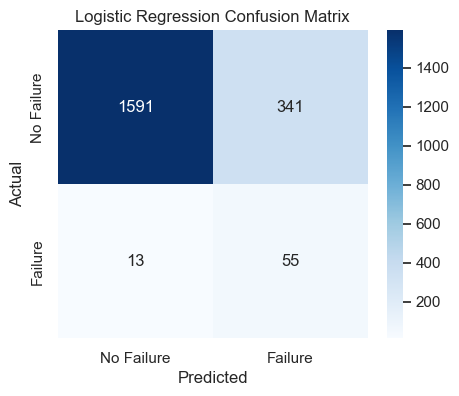


Decision Tree Classification Report
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.69      0.60      0.65        68

    accuracy                           0.98      2000
   macro avg       0.84      0.80      0.82      2000
weighted avg       0.98      0.98      0.98      2000



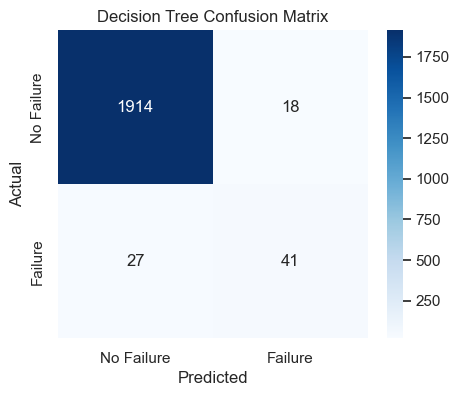

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.8230,0.138889,0.808824,0.237069,0.906581
1,Decision Tree,0.9775,0.694915,0.602941,0.645669,0.796812


In [43]:
def evaluate_model(name, estimator, X_test, y_test):
    """Evaluate a fitted classifier and return important metrics."""
    y_pred = estimator.predict(X_test)
    y_proba = estimator.predict_proba(X_test)[:, 1] if hasattr(estimator, "predict_proba") else None

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
    }

    print(f"\n{name} Classification Report")
    print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Failure", "Failure"], yticklabels=["No Failure", "Failure"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return metrics

results = []
for model_name, search in model_searches.items():
    results.append(evaluate_model(model_name, search["best_estimator"], X_test, y_test))

# For predictive maintenance, recall is often the most important metric
# because missing an actual failure can be more expensive than a false alarm.
results_df = pd.DataFrame(results).sort_values(by="recall", ascending=False)
results_df

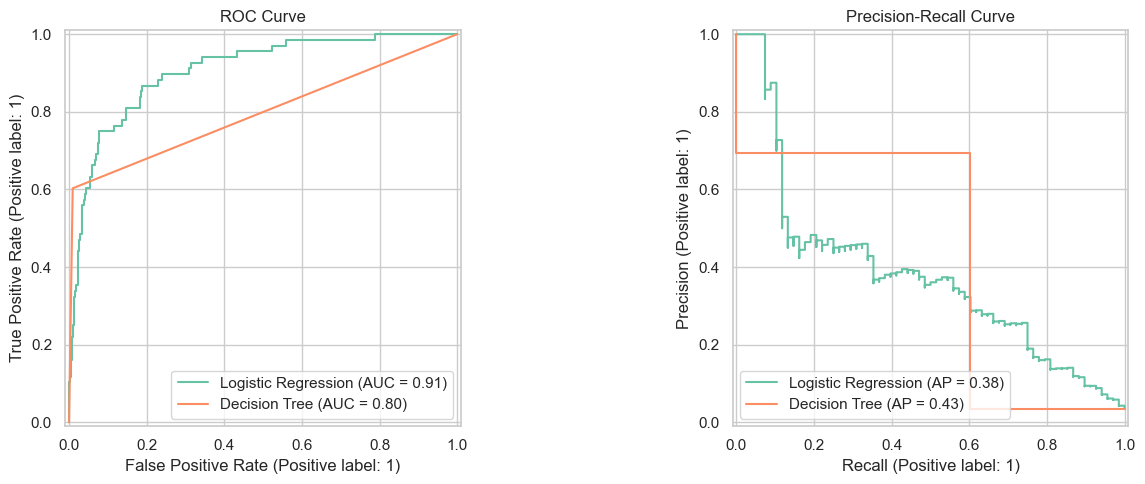

In [44]:
# Plot ROC curves and Precision-Recall curves for model comparison.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, search in model_searches.items():
    RocCurveDisplay.from_estimator(search["best_estimator"], X_test, y_test, ax=axes[0], name=model_name)
    PrecisionRecallDisplay.from_estimator(search["best_estimator"], X_test, y_test, ax=axes[1], name=model_name)
axes[0].set_title("ROC Curve")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

## 8. Which Metric Is Best Here?

For predictive maintenance, the business risk of a missed machine failure is usually high: downtime, safety issues, production loss, and repair cost. Because of that:

- **Accuracy** is not the best primary metric because the dataset is imbalanced. A model can predict `No Failure` most of the time and still look accurate.
- **Precision** matters when maintenance actions are very expensive and false alarms must be minimized.
- **Recall** matters when missing a true failure is more costly than checking a machine unnecessarily.
- **F1-score** is the best default metric here because it balances precision and recall for the rare failure class.

Recommended choice:
- Use **Recall** as the primary metric when missed failures are very costly.
- Use **F1-score** when the business wants a balanced tradeoff between catching failures and avoiding false alarms.
- In this notebook, the final model is selected by **Recall** because predictive maintenance usually prioritizes catching real failures.

## 9. Select and Save Best Model

The best model is selected by test Recall and saved as a pickle file. The saved object includes the full preprocessing pipeline, so raw input columns can be passed directly during inference.

In [45]:
# Since this is predictive maintenance, select the model with the best Recall.
# If Logistic Regression has the highest recall in results_df, then it is fair to say it is best for this business objective.
best_model_name = results_df.iloc[0]["model"]
best_model = model_searches[best_model_name]["best_estimator"]

model_bundle = {
    "model_name": best_model_name,
    "model": best_model,
    "feature_columns": X.columns.tolist(),
    "selection_metric": "recall",
    "test_metrics": results_df.iloc[0].to_dict(),
}

model_path = MODEL_DIR / "predictive_maintenance_model.pkl"
with open(model_path, "wb") as file:
    pickle.dump(model_bundle, file)

print(f"Best model by Recall: {best_model_name}")
print(f"Saved pickle model to: {model_path}")

Best model by Recall: Logistic Regression
Saved pickle model to: d:\Users data\Documents\Project_1_Predictive Maintainence\models\predictive_maintenance_model.pkl


In [46]:
# Quick load test to confirm the pickle artifact works.
with open(model_path, "rb") as file:
    loaded_bundle = pickle.load(file)

loaded_model = loaded_bundle["model"]
sample_predictions = loaded_model.predict(X_test.head())
print("Sample predictions:", sample_predictions)

Sample predictions: [1 1 1 0 1]


## Final Notes

This notebook keeps outliers instead of removing them automatically because unusual sensor readings may indicate failure behavior. The preprocessing is wrapped inside model pipelines to prevent data leakage: scaling and encoding are learned only from the training data during tuning and final fitting.